In [1]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
import torch

X shape: (2000, 2)
First 5 X:
 [[ 1.7765071   0.19275202]
 [ 0.39780872  0.93039011]
 [ 0.49530794 -0.31832132]
 [-0.94894379  0.16301974]
 [ 0.48495693 -0.33816023]]
Mean of X: [0.49921708 0.2507061 ]
Std of X: [0.87202523 0.50447609]


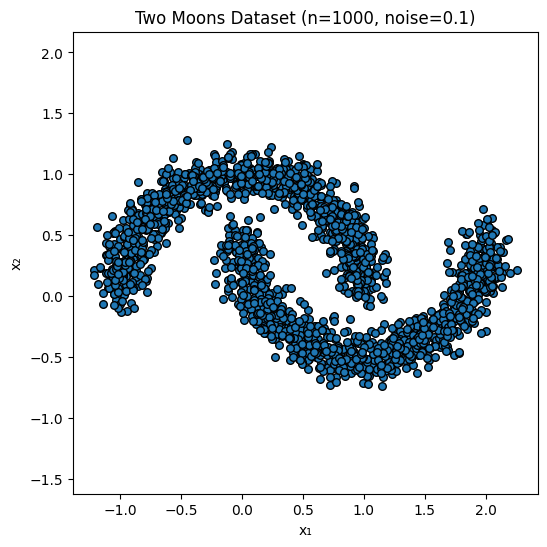

In [2]:
#  Generate data
X, _ = make_moons(n_samples=2000, noise=0.1, random_state=42)
# Inspect shapes and first few rows
print("X shape:", X.shape)    
print("First 5 X:\n", X[:5])
print("Mean of X:", X.mean(axis=0))
print("Std of X:", X.std(axis=0))


plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], edgecolor='k', s=30)
plt.title("Two Moons Dataset (n=1000, noise=0.1)")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.axis("equal")
plt.show()

## Sanity Check: 
Identity of forward and inverse pass is established:

In [3]:
from affine_coupling import AffineCoupling
from affine_coupling import NormalizingFlow

with torch.no_grad():
    ac = AffineCoupling(size=2, d=1, hidden_size=64) 
    ac.test_identity(tolerance=1e-6)

    nf = NormalizingFlow(input_dim=2, num_layers=4, hidden_size=64)
    nf.test_identity(tolerance=1e-6)

Min: 0.0, Max: 0.0
Min: -4.470348358154297e-08, Max: 1.7881393432617188e-07


## Training the Normalizing Flow
Batch Size: 64
Learning Rate: 0.001
Epochs: 100
Optimizer: AdamW
- $\beta_1$: 0.9
- $\beta_2$: 0.999
- Weight decay: 0.01

To get a better understanding of the model's reconstructive capabilities, we calculate the directed Hausdorff-Distance (Taha and Hanbury, 2015) between the generated samples and the original point-cloud. To better understand the performance, we center the reconstruction to standard deviation and mean of original distribution.

Config file not found: config.yaml
Epoch 1, Loss: 163.8857
Hausdorff distance: 1.7470
Epoch 2, Loss: 154.7196
Hausdorff distance: 1.2862
Epoch 3, Loss: 142.8062
Hausdorff distance: 1.1847
Epoch 4, Loss: 128.4270
Hausdorff distance: 2.0119
Epoch 5, Loss: 130.4930
Hausdorff distance: 1.8419
Epoch 6, Loss: 136.6437
Hausdorff distance: 2.1969
Epoch 7, Loss: 126.1913
Hausdorff distance: 1.0812
Epoch 8, Loss: 119.5423
Hausdorff distance: 2.1392
Epoch 9, Loss: 131.2519
Hausdorff distance: 1.0159
Epoch 10, Loss: 114.4594
Hausdorff distance: 1.3567
Epoch 11, Loss: 119.0975
Hausdorff distance: 0.8207
Epoch 12, Loss: 128.5579
Hausdorff distance: 1.6749
Epoch 13, Loss: 122.4870
Hausdorff distance: 1.0692
Epoch 14, Loss: 130.6652
Hausdorff distance: 1.4361
Epoch 15, Loss: 111.2146
Hausdorff distance: 1.1651
Epoch 16, Loss: 119.2285
Hausdorff distance: 1.7325
Epoch 17, Loss: 122.6491
Hausdorff distance: 0.8062
Epoch 18, Loss: 111.1780
Hausdorff distance: 0.5983
Epoch 19, Loss: 130.1039
Hausdorff dis

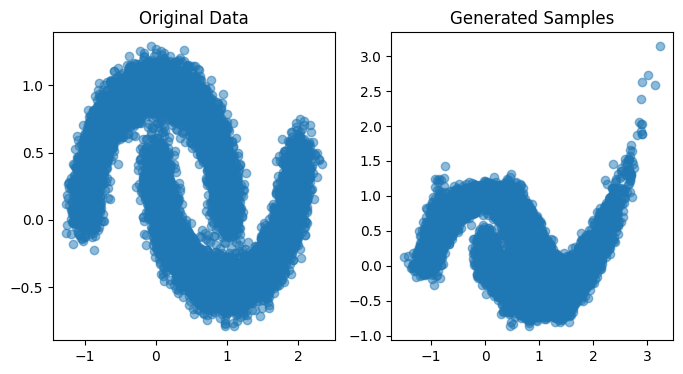

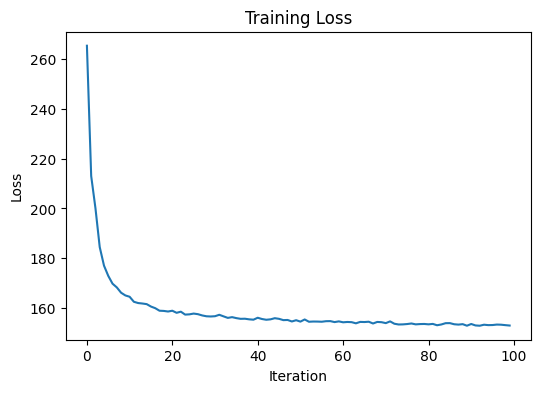

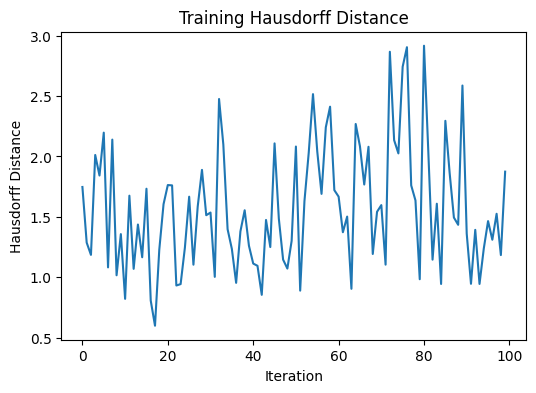

In [8]:
import torch.utils.data as data
from affine_coupling import NormalizingFlow
from config import Config
from sklearn.datasets import make_moons
from train import train_loop
import numpy as np

config = Config('config.yaml')

np.random.seed(42)
torch.manual_seed(42)


X, _ = make_moons(n_samples=config.samples, noise=0.1)
x_tensor = torch.tensor(X, dtype=torch.float32)
dataset = data.TensorDataset(x_tensor)
dataloader = data.DataLoader(dataset, batch_size=config.batch_size, shuffle=True)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(12000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()


## Alternative Masks
The default masks the first dimension. Here, we switch the dimension, and leave the mask altogether. 

Epoch 1, Loss: 167.2191
Hausdorff distance: 1.7169
Epoch 2, Loss: 157.9684
Hausdorff distance: 1.5054
Epoch 3, Loss: 155.7231
Hausdorff distance: 0.9873
Epoch 4, Loss: 145.8468
Hausdorff distance: 1.1094
Epoch 5, Loss: 138.6817
Hausdorff distance: 1.2949
Epoch 6, Loss: 147.5967
Hausdorff distance: 1.5551
Epoch 7, Loss: 131.6192
Hausdorff distance: 1.6796
Epoch 8, Loss: 157.5820
Hausdorff distance: 1.3737
Epoch 9, Loss: 139.2819
Hausdorff distance: 1.9049
Epoch 10, Loss: 151.7026
Hausdorff distance: 1.4622
Epoch 11, Loss: 148.5210
Hausdorff distance: 1.6172
Epoch 12, Loss: 135.5547
Hausdorff distance: 1.7017
Epoch 13, Loss: 125.1778
Hausdorff distance: 1.8585
Epoch 14, Loss: 124.0221
Hausdorff distance: 1.7458
Epoch 15, Loss: 122.6651
Hausdorff distance: 1.2181
Epoch 16, Loss: 120.7627
Hausdorff distance: 1.4782
Epoch 17, Loss: 121.4500
Hausdorff distance: 0.9043
Epoch 18, Loss: 129.2724
Hausdorff distance: 2.1790
Epoch 19, Loss: 115.4168
Hausdorff distance: 0.9457
Epoch 20, Loss: 132.4

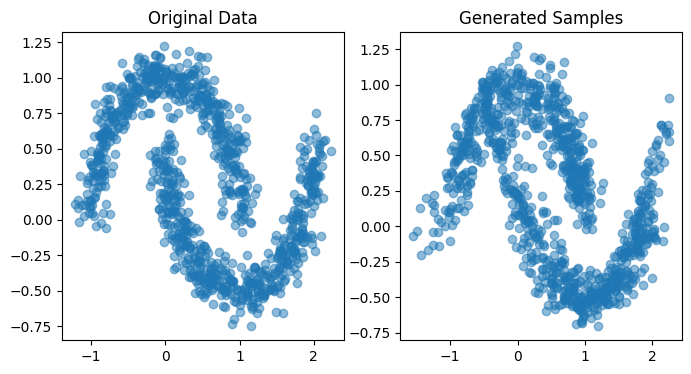

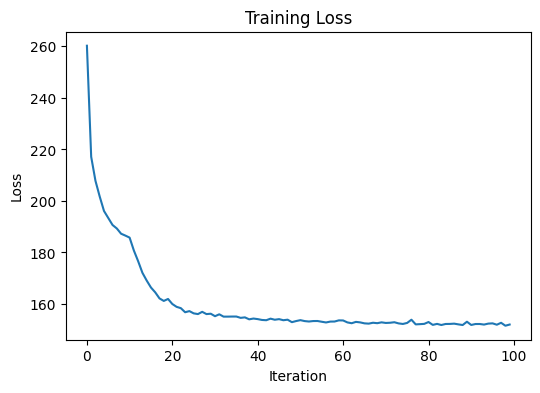

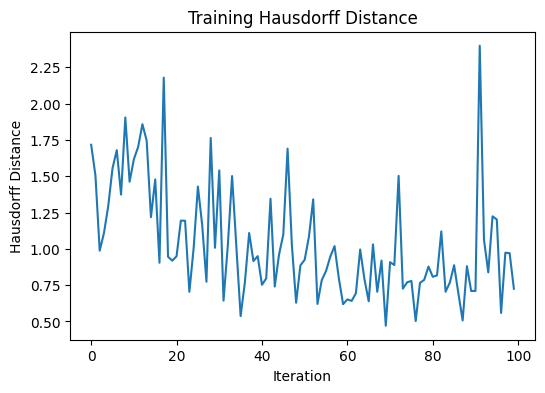

In [5]:
mask = torch.zeros(2)
mask[0] = 1.

np.random.seed(6)
torch.manual_seed(6)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size, mask=mask)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()


No mask:

/Users/konradgoldenbaum/Developement/M4ML-2025-Normalizing-Flows/.venv/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Epoch 1, Loss: 240.7587
Hausdorff distance: 1.5925
Epoch 2, Loss: 242.0953
Hausdorff distance: 1.3027
Epoch 3, Loss: 230.9899
Hausdorff distance: 1.5636
Epoch 4, Loss: 243.8472
Hausdorff distance: 1.4347
Epoch 5, Loss: 237.9136
Hausdorff distance: 1.2460
Epoch 6, Loss: 238.3623
Hausdorff distance: 1.4639
Epoch 7, Loss: 242.9248
Hausdorff distance: 1.4185
Epoch 8, Loss: 245.8542
Hausdorff distance: 1.2936
Epoch 9, Loss: 238.0349
Hausdorff distance: 1.2438
Epoch 10, Loss: 234.9500
Hausdorff distance: 1.1319
Epoch 11, Loss: 228.3152
Hausdorff distance: 1.7416
Epoch 12, Loss: 238.1277
Hausdorff distance: 1.2050
Epoch 13, Loss: 228.3735
Hausdorff distance: 1.3802
Epoch 14, Loss: 242.9248
Hausdorff distance: 1.2970
Epoch 15, Loss: 242.5750
Hausdorff distance: 1.1341
Epoch 16, Loss: 238.0081
Hausdorff distance: 1.7000
Epoch 17, Loss: 245.1579
Hausdorff distance: 1.4571
Epoch 18, Loss: 242.8584
Hausdorff distance: 1.4988
Epoch 19, Loss: 238.8774
Hausdorff distance: 1.3910
Epoch 20, Loss: 240.6

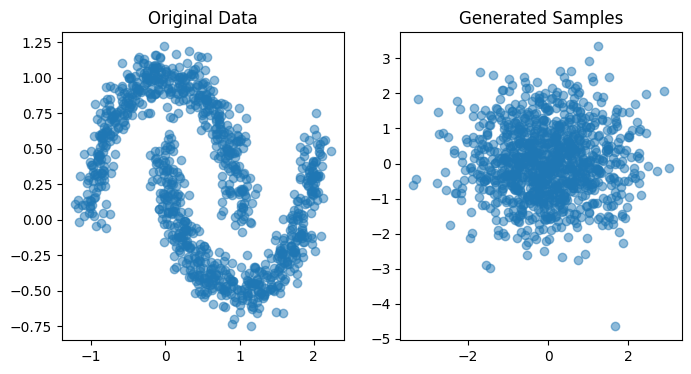

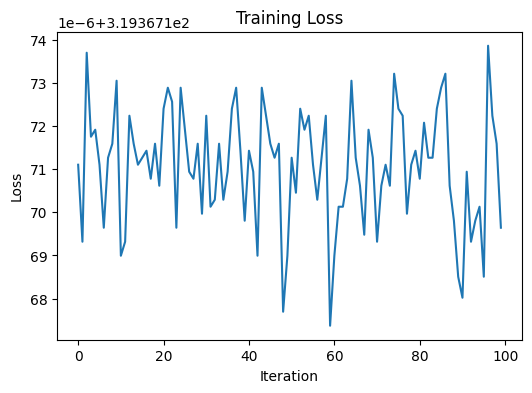

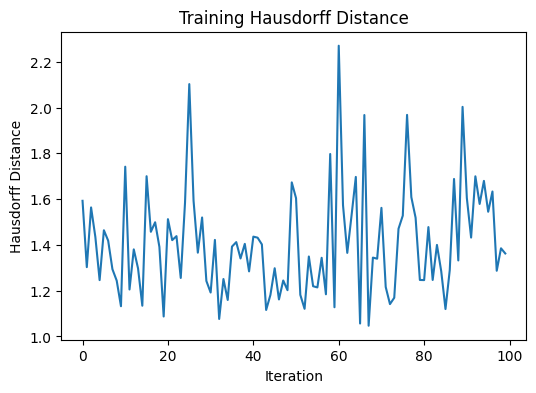

In [6]:
mask = torch.ones(2)

np.random.seed(6)
torch.manual_seed(6)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size, mask=mask)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()


All mask:

Epoch 1, Loss: 212.8470
Hausdorff distance: 1.3364
Epoch 2, Loss: 187.1716
Hausdorff distance: 1.2935
Epoch 3, Loss: 189.1281
Hausdorff distance: 1.7297
Epoch 4, Loss: 199.2757
Hausdorff distance: 1.1052
Epoch 5, Loss: 187.5838
Hausdorff distance: 1.6801
Epoch 6, Loss: 195.6470
Hausdorff distance: 1.3631
Epoch 7, Loss: 195.2111
Hausdorff distance: 1.3261
Epoch 8, Loss: 185.7860
Hausdorff distance: 1.4622
Epoch 9, Loss: 197.8861
Hausdorff distance: 1.3928
Epoch 10, Loss: 189.8436
Hausdorff distance: 1.1517
Epoch 11, Loss: 187.6134
Hausdorff distance: 1.5432
Epoch 12, Loss: 192.7229
Hausdorff distance: 0.9356
Epoch 13, Loss: 184.8700
Hausdorff distance: 1.2988
Epoch 14, Loss: 189.8820
Hausdorff distance: 1.5612
Epoch 15, Loss: 195.6872
Hausdorff distance: 1.1008
Epoch 16, Loss: 187.5455
Hausdorff distance: 1.4115
Epoch 17, Loss: 193.2485
Hausdorff distance: 1.2092
Epoch 18, Loss: 189.5937
Hausdorff distance: 1.1340
Epoch 19, Loss: 196.5978
Hausdorff distance: 1.3658
Epoch 20, Loss: 189.5

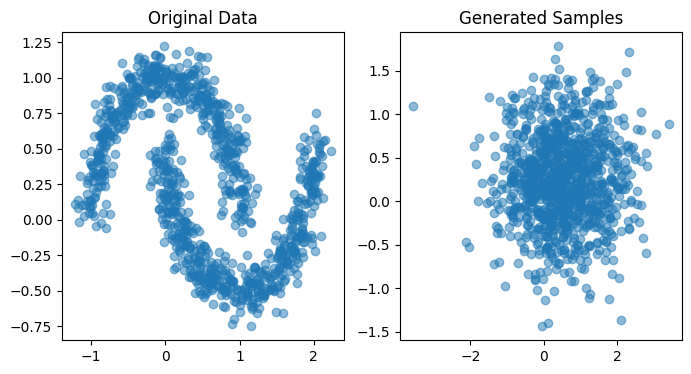

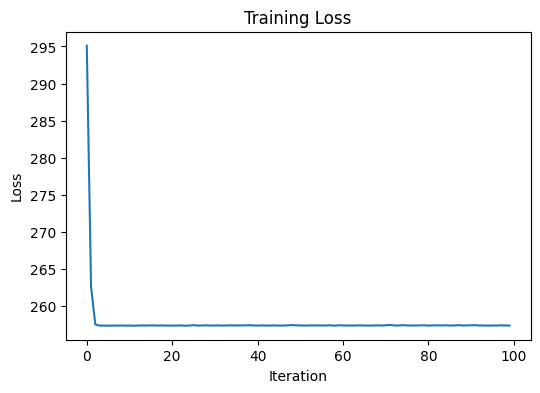

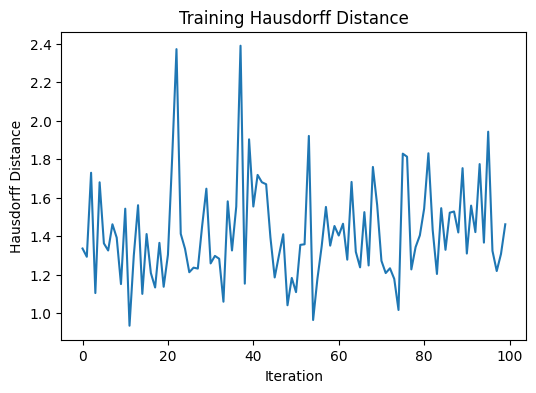

In [7]:
mask = torch.zeros(2)
np.random.seed(6)
torch.manual_seed(6)

model = NormalizingFlow(input_dim=config.input_dim, num_layers=config.num_layers, hidden_size=config.hidden_size, mask=mask)
model.train()
model, loss_history, hausdorff_hist = train_loop(config, model, dataloader)

# Sampling and visualization (optional)
with torch.no_grad():
    model.eval()
    z_samples = torch.randn(1000, config.input_dim)
    x_samples = model.inverse(z_samples)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Data")
    # Pick as many random points as there are x_samples
    idx = np.random.choice(X.shape[0], size=x_samples.shape[0], replace=False)
    plt.scatter(X[idx, 0], X[idx, 1], alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.title("Generated Samples")
    plt.scatter(x_samples[:, 0], x_samples[:, 1], alpha=0.5)
    plt.show()


    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(hausdorff_hist)
    plt.xlabel("Iteration")
    plt.ylabel("Hausdorff Distance")
    plt.title("Training Hausdorff Distance")
    plt.show()
